#  Task 1 - Iris Flower Classification

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

Matplotlib is building the font cache; this may take a moment.


## 2. Load Iris Dataset

In [2]:
iris = load_iris()

print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [3]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)

df['species'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df['species'] = df['species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## 3. Data Exploration

In [24]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

Shape of dataset: (150, 5)

Column names:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='str')

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Basic statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.3000

In [25]:
print(df['species'].value_counts())

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


## 4. Exploratory Data Analysis

## 4.1 PairPlot

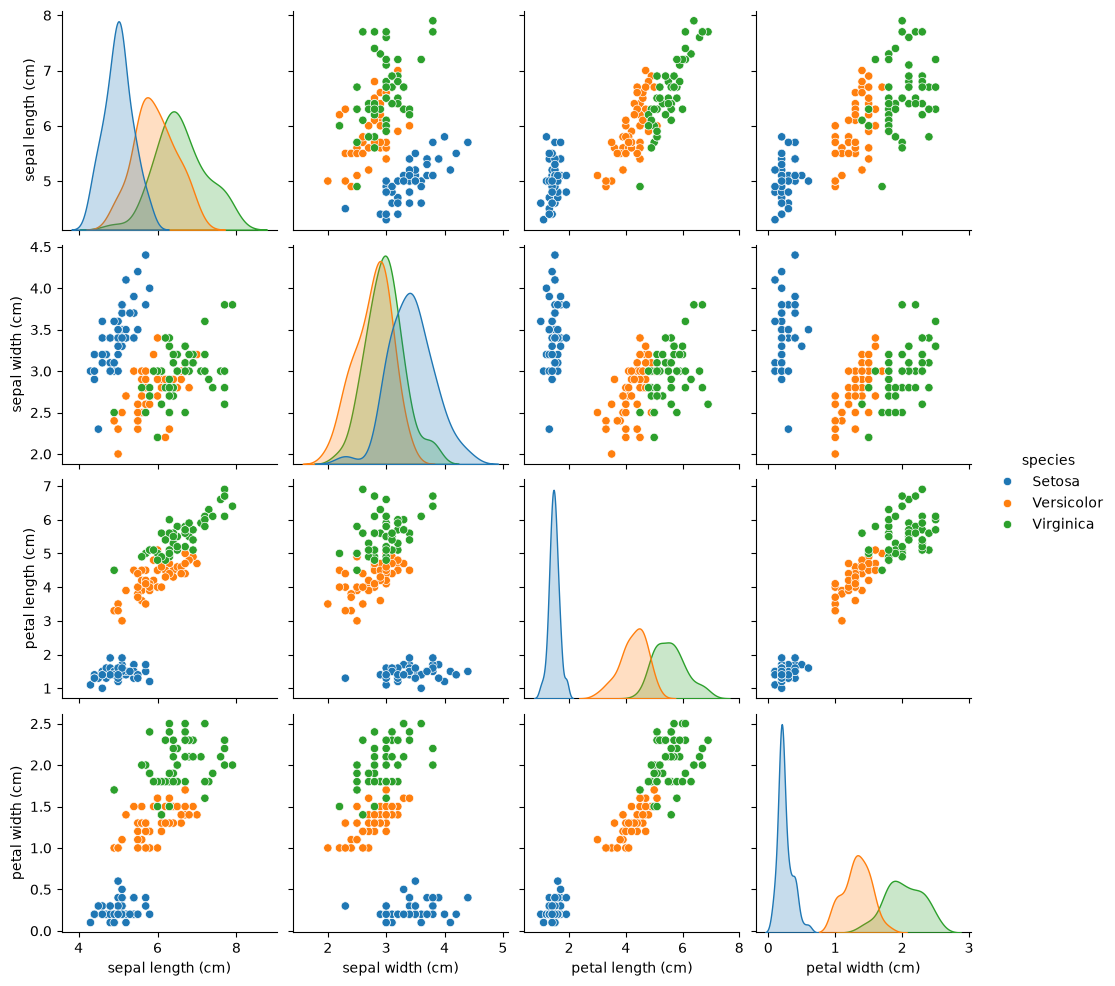

In [27]:
sns.pairplot(df, hue='species')
plt.show()

## 4.2 Box Plot

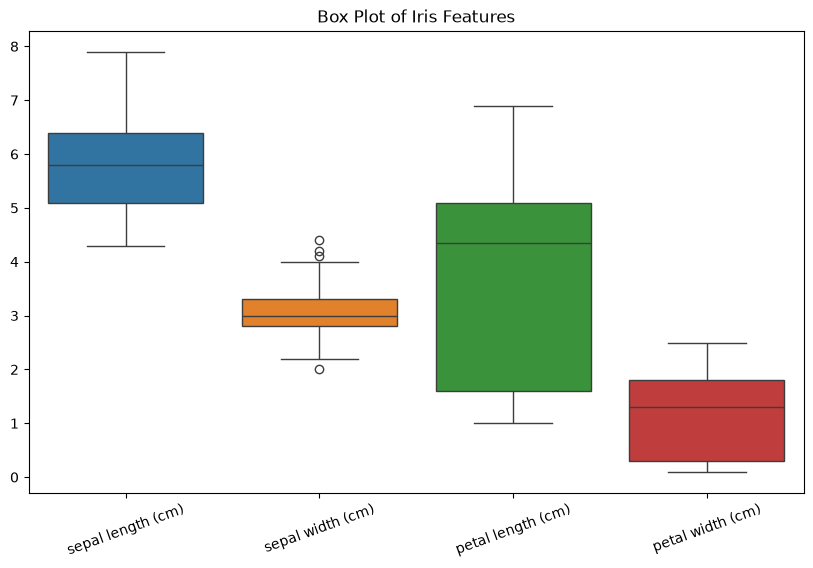

In [28]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df.drop(columns='species'))

plt.title('Box Plot of Iris Features')
plt.xticks(rotation=20)
plt.show()

## 4.3 Correlation Heatmap

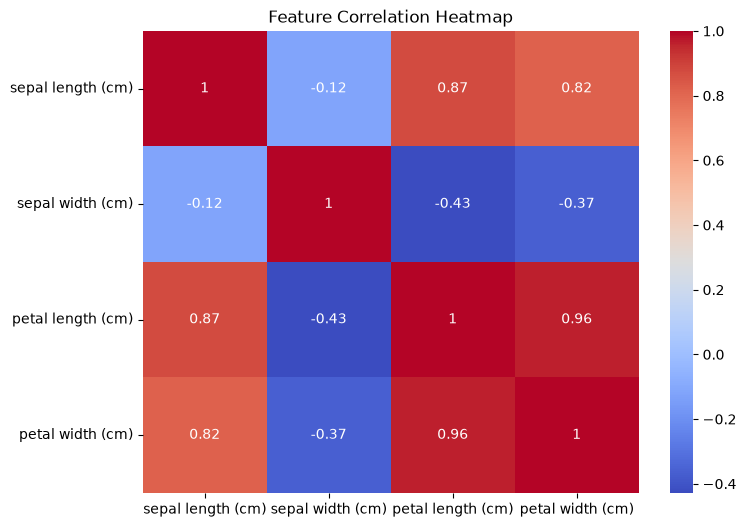

In [9]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.drop(columns='species').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')
plt.show()

## 5.Feature Selection

In [10]:
X = df.drop(columns='species')
y = df['species']

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    Setosa
1    Setosa
2    Setosa
3    Setosa
4    Setosa
Name: species, dtype: str


## 6. Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


## 7. Model 1 - Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=200)

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

print("Predictions:")
print(y_pred1)

Predictions:
['Setosa' 'Virginica' 'Versicolor' 'Versicolor' 'Setosa' 'Versicolor'
 'Setosa' 'Setosa' 'Virginica' 'Versicolor' 'Virginica' 'Virginica'
 'Virginica' 'Versicolor' 'Setosa' 'Setosa' 'Setosa' 'Versicolor'
 'Versicolor' 'Virginica' 'Setosa' 'Virginica' 'Versicolor' 'Virginica'
 'Virginica' 'Virginica' 'Versicolor' 'Setosa' 'Virginica' 'Setosa']


In [13]:
from sklearn.metrics import accuracy_score

accuracy1 = accuracy_score(y_test, y_pred1)

print("Logistic Regression Accuracy:", accuracy1)

Logistic Regression Accuracy: 0.9666666666666667


## 8. Model 2 - K-Nearest Neighbors (KNN)

In [14]:
from sklearn.neighbors import KNeighborsClassifier

model2 = KNeighborsClassifier(n_neighbors=5)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Predictions:")
print(y_pred2)

Predictions:
['Setosa' 'Virginica' 'Versicolor' 'Versicolor' 'Setosa' 'Versicolor'
 'Setosa' 'Setosa' 'Virginica' 'Versicolor' 'Virginica' 'Virginica'
 'Virginica' 'Versicolor' 'Setosa' 'Setosa' 'Setosa' 'Versicolor'
 'Versicolor' 'Virginica' 'Setosa' 'Virginica' 'Versicolor' 'Virginica'
 'Virginica' 'Versicolor' 'Versicolor' 'Setosa' 'Virginica' 'Setosa']


In [15]:
accuracy2 = accuracy_score(y_test, y_pred2)

print("KNN Accuracy:", accuracy2)

KNN Accuracy: 1.0


## 9. Model Evaluation

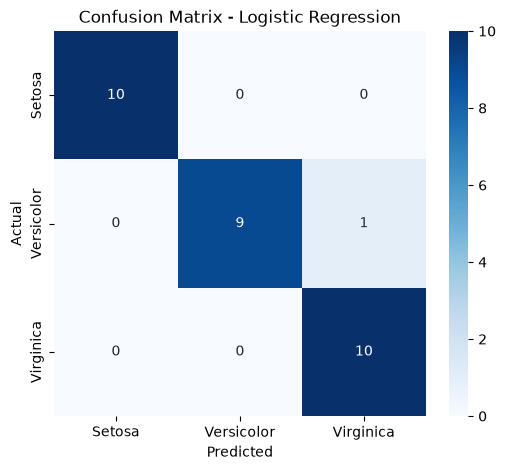

In [16]:
from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test, y_pred1)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm1,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Setosa', 'Versicolor', 'Virginica'],
    yticklabels=['Setosa', 'Versicolor', 'Virginica']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [17]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred1))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      0.90      0.95        10
   Virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



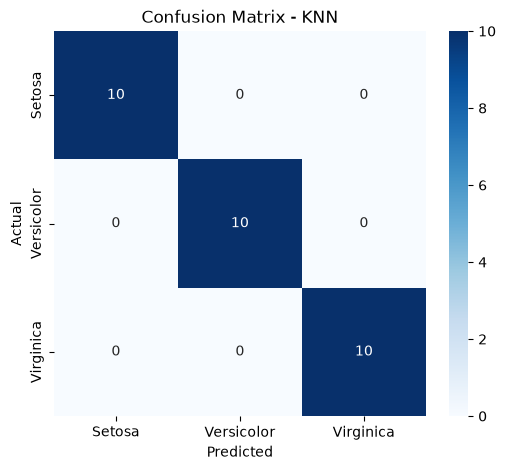

In [18]:
cm2 = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Setosa', 'Versicolor', 'Virginica'],
    yticklabels=['Setosa', 'Versicolor', 'Virginica']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - KNN')
plt.show()

In [19]:
print("KNN Classification Report:")
print(classification_report(y_test, y_pred2))

KNN Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00        10
   Virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 10. Model Comparison

In [20]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN'],
    'Accuracy': [accuracy1, accuracy2]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.966667
1                  KNN  1.000000


In [21]:
if accuracy1 > accuracy2:
    best_model = "Logistic Regression"
elif accuracy2 > accuracy1:
    best_model = "KNN"
else:
    best_model = "Both models have the same accuracy"

print("Final Model Comparison")
print("----------------------")
print(f"Logistic Regression Accuracy: {accuracy1:.2%}")
print(f"KNN Accuracy: {accuracy2:.2%}")
print(f"Result: {best_model}")

Final Model Comparison
----------------------
Logistic Regression Accuracy: 96.67%
KNN Accuracy: 100.00%
Result: KNN


KNN achieved an accuracy of 100%, while Logistic Regression achieved 96.67% accuracy.

Therefore, KNN performed better on the test dataset for this Iris classification task.

# OIBSIP Task 1 - Iris Flower Classification

## Objective
To build a machine learning classification model that predicts the species of an iris flower using its sepal and petal measurements.

## Dataset
The Iris dataset contains measurements of iris flowers belonging to three species:
- Setosa
- Versicolor
- Virginica